In [1]:
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from pathlib import Path
import random
import numpy as np
import torch
import pandas as pd

# from models import TwoHeadMLPNet, SingleOutMLPNet
from shap_helpers import (compute_shap_3out, 
                          _ensure_2d_shap, 
                          mean_abs_shap, 
                          topk_table, 
                          global_table,
                          save_fig, 
                          cosine_spearman)

### MLP

In [2]:
OUTDIR = Path("./FiguresPaper")
SHAP_DIR = OUTDIR / "shap_values"
FIG_DIR = SHAP_DIR / "figs"
TAB_DIR = SHAP_DIR / "tables"

### Transformer

In [3]:
shap_tr = np.load("./Results/shap_values/shap_values.npz", allow_pickle=True)

TOPK = 6
# mtag = "TR_multi"

In [4]:
shap_tr

NpzFile './Results/shap_values/shap_values.npz' with keys: X_ex, X_bg, shap_vals, feature_names, method

In [5]:
sv_list = [shap_tr['shap_vals']]
X_ex = shap_tr["X_ex"]
feature_names = shap_tr["feature_names"].tolist()

/home/umberto/Escritorio/Simulations/Python/VirtualEnvironments/PythonVirtualEnvironment/lib/python3.12/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


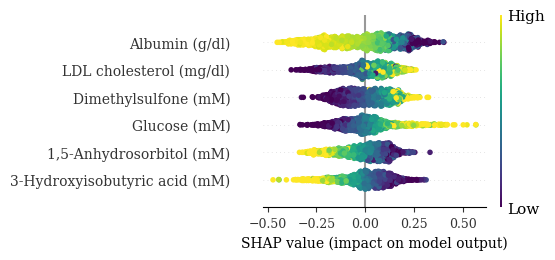

In [37]:
sv2 = _ensure_2d_shap(shap_tr['shap_vals'], tag="age")
ma = mean_abs_shap(sv2, tag="age")

df_top = topk_table(ma, feature_names, TOPK, tag="age", tabdir=TAB_DIR)
_ = global_table(ma, feature_names, tag="age", tabdir=TAB_DIR)

top_feats = df_top["feature"].tolist()
top_idx = [feature_names.index(f) for f in top_feats]
sv_top = sv2[:, top_idx]
X_ex_top = X_ex[:, top_idx]

plt.rcParams.update({"font.family": "serif"})

# plt.figure(figsize=(3.6, 1.5))
plt.figure()
shap.summary_plot(sv_top, features=X_ex_top, feature_names=top_feats, show=False, 
                  cmap="viridis", plot_size=(3.6, 2.5))

ax = plt.gca()
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=10)

cbar = plt.gcf().axes[-1]
cbar.set_ylabel("")

plt.savefig(f'Results/SHAP_top{TOPK}.pdf', dpi=600, bbox_inches="tight")

plt.show()